[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter4_seminar_notebook.ipynb)

# Time Series Analysis — Seminar 4: Seasonality and forecasting

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 4; the slides give the formulas ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_4'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 4 (`fit_sarima`, `ljung_box`, `acf_bars`, `load_daily`, `load_exog`, `dm_raw`, `working_days`) and the seminar functions: `seasonal_differences`, `airline_acf`, `dm_by_hand`, `b1_gdp`, `b3_load_cv`.

In [ ]:
import logging
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import MSTL
from statsmodels.regression.linear_model import OLS
from dateutil.easter import easter, EASTER_ORTHODOX
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
SEED = 2026
GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
GDP_SCA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
RETAIL = ('sts_trtu_m', 'M.VOL_SLS.G47.NSA.I21.RO')
RETAIL_SCA = ('sts_trtu_m', 'M.VOL_SLS.G47.SCA.I21.RO')
FOOD = ('sts_trtu_m', 'M.VOL_SLS.G47_FOOD.NSA.I21.RO')
IPI = ('sts_inpr_m', 'M.PRD.B-D.NSA.I21.RO')
TOUR = ('tour_occ_nim', 'M.TOTAL.NR.I551-I553.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
GDP_START = '2000-01-01'
ENTSOE = 'https://www.entsoe.eu/publications/data/power-stats/{y}/monthly_hourly_load_values_{y}.csv'
LOAD_FILE = 'ch4_ro_load_hourly.csv'
LOAD_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_04/ch4_ro_load_hourly.csv'
LOAD_YEARS = (2022, 2023, 2024, 2025, 2026)
LOAD_END = '2026-06-30'
CV_FIRST, CV_STEP, CV_H = '2025-06-30', 14, 14
BAND_COL = st.IDAred
MODEL_COL = {'Seasonal naive': st.Amber, 'ETS': st.Teal, 'SARIMA': st.Purple, 'DHR': st.MainBlue, 'TBATS': st.Forest, 'Prophet': st.Orange, 'Combination': st.IDAred}
GDP_GRID = [((0, 1, 1), (0, 1, 1)), ((1, 1, 0), (0, 1, 1)), ((1, 1, 1), (0, 1, 1)), ((0, 1, 2), (0, 1, 1)), ((2, 1, 0), (0, 1, 1)), ((0, 1, 1), (1, 1, 0)), ((1, 1, 0), (1, 1, 0)), ((0, 1, 1), (1, 1, 1)), ((0, 1, 0), (0, 1, 1)), ((0, 1, 1), (0, 1, 0))]
HERE = "."


def have(pkg):
    """True if an optional package (tbats, prophet, pmdarima) is installed."""
    import importlib.util
    return importlib.util.find_spec(pkg) is not None


def eurostat_log(key, start=None):
    """Natural log of a Eurostat series (monthly or quarterly), from `start`."""
    s = np.log(read_eurostat(*key))
    s = s.loc[start:] if start else s
    s.index.freq = None
    return s


def ro_holidays(years):
    """Romanian public holidays (Orthodox Easter and Pentecost from dateutil): date -> name."""
    out = {}
    for y in years:
        e = pd.Timestamp(easter(y, EASTER_ORTHODOX))
        day = pd.Timedelta(days=1)
        hol = {'New Year': [f'{y}-01-01', f'{y}-01-02'], 'Union Day': [f'{y}-01-24'],
               'Easter': [e - 2 * day, e, e + day], 'Labour Day': [f'{y}-05-01'], "Children's Day": [f'{y}-06-01'],
               'Pentecost': [e + 49 * day, e + 50 * day], 'Assumption': [f'{y}-08-15'], "St Andrew's Day": [f'{y}-11-30'],
               'National Day': [f'{y}-12-01'], 'Christmas': [f'{y}-12-25', f'{y}-12-26']}
        if y >= 2024:
            hol['Epiphany'] = [f'{y}-01-06', f'{y}-01-07']
        for k, v in hol.items():
            for x in v:
                out[pd.Timestamp(x)] = k
    return pd.Series(out, name='holiday').sort_index()


def load_hourly(years=LOAD_YEARS, end=LOAD_END):
    """Hourly electricity load of Romania (MW, hourly average), ENTSO-E 'monthly hourly load values'.
    Reads the extract ch4_ro_load_hourly.csv (local or from the TSA repository); otherwise downloads the yearly ENTSO-E
    files (about 40 MB each) and keeps Romania. Returns the series in UTC+2 (Romanian winter time, no clock change),
    with isolated one-hour glitches (more than 30% away from both neighbours) and missing hours interpolated."""
    s = None
    local = [os.path.join(HERE, LOAD_FILE)] + [os.path.join(d, 'Quantlets', 'Ch_04', LOAD_FILE) for d in ('.', '..', '../..', '../../..')]
    for src in [p for p in local if os.path.exists(p)] + [LOAD_RAW]:
        try:
            s = pd.read_csv(src, index_col=0, parse_dates=True).iloc[:, 0]
            break
        except Exception:
            continue
    if s is None:
        parts = []
        for y in years:
            url = ENTSOE.format(y=y)
            head = pd.read_csv(url, nrows=2, encoding='utf-8-sig', sep=None, engine='python')
            sep = '\t' if '\t' in ''.join(head.columns) or len(head.columns) == 1 else ','
            t = pd.read_csv(url, sep=sep, usecols=['DateUTC', 'CountryCode', 'Value'], encoding='utf-8-sig')
            t = t[t['CountryCode'] == 'RO']
            parts.append(pd.Series(t['Value'].astype(float).values,
                                   index=pd.to_datetime(t['DateUTC'], format='%d-%m-%Y %H:%M')))
        s = pd.concat(parts)
        s = s[~s.index.duplicated()].sort_index().rename('load_MW')
        s.index.name = 'date_utc'
        try:
            s.to_csv(os.path.join(HERE, LOAD_FILE) if os.path.isdir(HERE) else LOAD_FILE)
        except OSError:
            pass
    s = s.loc[:pd.Timestamp(end) + pd.Timedelta(hours=21)]
    s.index = s.index + pd.Timedelta(hours=2)
    s = s.reindex(pd.date_range(s.index[0], s.index[-1], freq='h'))
    r = s / ((s.shift(1) + s.shift(-1)) / 2)
    s[(r < 0.7) | (r > 1.3)] = np.nan
    return s.interpolate().rename('load')


def load_daily(end=LOAD_END):
    """Daily mean load in GW (Romanian winter time), 1 January 2022 - 30 June 2026."""
    d = load_hourly().resample('D').mean() / 1000
    return d.loc['2022-01-01':end].rename('load')


def sample_acf(x, nlags=20):
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=24, df=None):
    """Ljung-Box Q*(m) with df degrees of freedom (m minus the number of ARMA parameters for residuals)."""
    x = np.asarray(x, float)
    T = len(x)
    r = sample_acf(x, m)
    q = T * (T + 2) * np.sum(r ** 2 / (T - np.arange(1, m + 1)))
    df = m if df is None else df
    return {'lb': float(q), 'df': int(df), 'lb_p': float(stats.chi2.sf(q, df))}


def acf_bars(ax, r, T, color=st.MainBlue, label='_nolegend_', band=True, mark=None):
    """Bars at lags 1..len(r), the +-1.96/sqrt(T) band, and vertical marks at seasonal lags."""
    lags = np.arange(1, len(r) + 1)
    if mark:
        for m in mark:
            ax.axvline(m, color=st.Orange, lw=0.8, ls=':', label='_nolegend_')
    ax.bar(lags, r, width=0.6, color=color, label=label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def date_axis(ax, kind='year'):
    """Readable date ticks: 'year' (one tick per year), 'month' (month initials), 'week' (day and month)."""
    if kind == 'year':
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    elif kind == 'month':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    else:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))


def polymul(a, b):
    return np.convolve(np.asarray(a, float), np.asarray(b, float))


def sarma_process(phi=(), theta=(), Phi=(), Theta=(), s=12):
    """Multiplicative seasonal ARMA phi(L)Phi(L^s) X_t = theta(L)Theta(L^s) e_t as an ArmaProcess (expanded lags)."""
    def seas(c, sign):
        v = np.zeros(s * len(c) + 1)
        v[0] = 1
        for i, x in enumerate(c):
            v[s * (i + 1)] = sign * x
        return v
    ar = polymul(np.r_[1, -np.asarray(phi, float)], seas(Phi, -1))
    ma = polymul(np.r_[1, np.asarray(theta, float)], seas(Theta, 1))
    return ArmaProcess(ar, ma)


def fit_sarima(y, order, sorder, exog=None, trend='n'):
    """Gaussian maximum likelihood of a SARIMA (statsmodels SARIMAX, exact likelihood after differencing)."""
    return SARIMAX(np.asarray(y, float), exog=exog, order=order, seasonal_order=sorder, trend=trend).fit(
        disp=False, maxiter=200)


def aicc(res, n):
    k = len(res.params)
    return float(res.aic + 2 * k * (k + 1) / max(n - k - 1, 1))


def fourier(idx, period, K, t0='2000-01-01'):
    """Fourier terms sin(2 pi k t / period), cos(2 pi k t / period), k = 1..K, with t in days (daily data) or in
    steps (integer index)."""
    if isinstance(idx, pd.DatetimeIndex):
        t = np.asarray((idx - pd.Timestamp(t0)).days, float)
    else:
        t = np.asarray(idx, float)
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin{k}_{period:g}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos{k}_{period:g}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=idx if isinstance(idx, pd.DatetimeIndex) else None)


def easter_share(idx, w=10):
    """Easter regressor of a monthly series: the share of the w days before Orthodox Easter Sunday that fall in each
    month (the 'easter[w]' regressor of X-13ARIMA-SEATS, with the Orthodox date)."""
    out = pd.Series(0.0, index=idx)
    for y in sorted(set(idx.year)):
        e = pd.Timestamp(easter(y, EASTER_ORTHODOX))
        days = pd.date_range(e - pd.Timedelta(days=w), e - pd.Timedelta(days=1))
        for m in days:
            key = pd.Timestamp(m.year, m.month, 1)
            if key in out.index:
                out[key] += 1 / w
    return out


def working_days(idx):
    """Number of Monday-Friday days that are not public holidays, in each month."""
    hol = set(ro_holidays(range(idx[0].year, idx[-1].year + 1)).index)
    return pd.Series([sum(1 for d in pd.date_range(m, m + pd.offsets.MonthEnd(0)) if d.dayofweek < 5 and d not in hol)
                      for m in idx], index=idx, dtype=float)


def load_exog(idx, K=4):
    """Regressors of the dynamic harmonic regression: K annual Fourier pairs, 6 weekday dummies (Sunday is the base),
    Orthodox Easter (Friday to Monday), other public holidays, the Christmas - New Year days (24 Dec - 2 Jan)."""
    X = fourier(idx, 365.25, K)
    for j, nm in enumerate(['mon', 'tue', 'wed', 'thu', 'fri', 'sat']):
        X[nm] = (idx.dayofweek == j).astype(float)
    hol = ro_holidays(range(idx[0].year, idx[-1].year + 1)).reindex(idx)
    X['easter'] = (hol == 'Easter').astype(float)
    X['xmas'] = (((idx.month == 12) & (idx.day >= 24)) | ((idx.month == 1) & (idx.day <= 2))).astype(float)
    X['holiday'] = (hol.notna() & (X['easter'] == 0) & (X['xmas'] == 0)).astype(float)
    return X


def select_orders(y):
    """Orders fixed once, on the data before the first forecast origin: SARIMA(p,0,q)(0,1,1)_7 and the ARMA errors
    of the dynamic harmonic regression, by AIC."""
    out = {}
    best = None
    for o in [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1)]:
        a = fit_sarima(y, o, (0, 1, 1, 7)).aic
        if best is None or a < best[0]:
            best = (a, o)
    out['sarima'] = best[1]
    best = None
    X = load_exog(y.index).values
    for o in [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1), (1, 1, 1)]:
        a = fit_sarima(y, o, (0, 0, 0, 0), exog=X, trend='c' if o[1] == 0 else 'n').aic
        if best is None or a < best[0]:
            best = (a, o)
    out['dhr'] = best[1]
    return out


def forecast_models(tr, h, orders, models=None):
    """h-day forecasts of every model from a training sample `tr` (daily load, GW)."""
    models = models or ['Seasonal naive', 'ETS', 'SARIMA', 'DHR', 'TBATS', 'Prophet']
    idx = pd.date_range(tr.index[-1] + pd.Timedelta(days=1), periods=h, freq='D')
    f = {}
    if 'Seasonal naive' in models:
        f['Seasonal naive'] = np.tile(tr.values[-7:], h // 7 + 1)[:h]
    if 'ETS' in models:
        f['ETS'] = ExponentialSmoothing(tr.values, trend='add', damped_trend=True, seasonal='add',
                                        seasonal_periods=7).fit().forecast(h)
    if 'SARIMA' in models:
        f['SARIMA'] = fit_sarima(tr, orders['sarima'], (0, 1, 1, 7)).forecast(h)
    if 'DHR' in models:
        o = orders['dhr']
        r = fit_sarima(tr, o, (0, 0, 0, 0), exog=load_exog(tr.index).values, trend='c' if o[1] == 0 else 'n')
        f['DHR'] = r.forecast(h, exog=load_exog(idx).values)
    if 'TBATS' in models and have('tbats'):
        from tbats import TBATS
        m = TBATS(seasonal_periods=[7, 365.25], use_box_cox=False, use_trend=False, use_damped_trend=False,
                  use_arma_errors=True, n_jobs=1).fit(tr.values)
        f['TBATS'] = np.asarray(m.forecast(steps=h))
    if 'Prophet' in models and have('prophet'):
        from prophet import Prophet
        H = ro_holidays(range(tr.index[0].year, idx[-1].year + 1))
        p = Prophet(holidays=pd.DataFrame({'ds': H.index, 'holiday': H.values}), daily_seasonality=False,
                    yearly_seasonality=True, weekly_seasonality=True)
        p.fit(pd.DataFrame({'ds': tr.index, 'y': tr.values}))
        f['Prophet'] = p.predict(pd.DataFrame({'ds': idx}))['yhat'].values
    combo = [k for k in f if k != 'Seasonal naive']
    f['Combination'] = np.mean([f[k] for k in combo], axis=0)
    return idx, f


def dm_test(e1, e2, h=1, loss='se'):
    """Diebold-Mariano test of equal accuracy (loss 'se' squared or 'ae' absolute errors), with the Newey-West
    variance on h - 1 lags and the Harvey-Leybourne-Newbold small-sample correction, Student t(n - 1) p-value.
    d_t = L(e1_t) - L(e2_t): a negative mean favours the first forecast."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = (e1 ** 2 - e2 ** 2) if loss == 'se' else (np.abs(e1) - np.abs(e2))
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    corr = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    hln = corr * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}


def dm_raw(l1, l2, h=1):
    """Diebold-Mariano test on two loss series (already computed), HLN correction, t(n - 1) p-value."""
    d = np.asarray(l1, float) - np.asarray(l2, float)
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n) * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}


def seasonal_differences(y, s=4, H=4):
    """Delta_s y_t, Delta Delta_s y_t and the seasonal naive forecasts y_{T+h} = y_{T+h-s}, h = 1..H."""
    y = np.asarray(y, float)
    ds = y[s:] - y[:-s]
    dds = ds[1:] - ds[:-1]
    snaive = [float(y[len(y) - s + (h - 1) % s]) for h in range(1, H + 1)]
    return {'ds': ds.tolist(), 'dds': dds.tolist(), 'snaive': snaive}


def airline_acf(theta, Theta, s=4, nlags=None):
    """ACF of w_t = (1 + theta L)(1 + Theta L^s) e_t: gamma(0)/sigma^2 and the nonzero autocorrelations."""
    nlags = nlags or s + 2
    g0 = (1 + theta ** 2) * (1 + Theta ** 2)
    r = sarma_process(theta=[theta], Theta=[Theta], s=s).acf(nlags + 1)[1:]
    return {'g0': g0, 'rho': {int(k + 1): float(v) for k, v in enumerate(r) if abs(v) > 1e-10}}


def dm_by_hand(e1, e2, scale=None, loss='se'):
    """MAE, RMSE (and MASE if `scale` is given) of two forecast-error series, and the Diebold-Mariano test on the
    loss differential d_t = L(e1_t) - L(e2_t) (one-step or non-overlapping windows: no autocovariance terms)."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    L = (lambda e: e ** 2) if loss == 'se' else np.abs
    d = L(e1) - L(e2)
    n = len(d)
    out = {'mae1': float(np.mean(np.abs(e1))), 'mae2': float(np.mean(np.abs(e2))),
           'rmse1': float(np.sqrt(np.mean(e1 ** 2))), 'rmse2': float(np.sqrt(np.mean(e2 ** 2))),
           'd': d.tolist(), 'dbar': float(d.mean()), 's2': float(np.mean((d - d.mean()) ** 2)),
           'n': n, 't_crit': float(stats.t.ppf(0.975, n - 1))}
    out['dm'] = out['dbar'] / np.sqrt(out['s2'] / n)
    out['hln'] = float(np.sqrt((n - 1) / n) * out['dm'])
    out['p'] = float(2 * stats.t.sf(abs(out['hln']), n - 1))
    if scale:
        out['mase1'], out['mase2'] = out['mae1'] / scale, out['mae2'] / scale
    return out


def b1_gdp(H=4, fname='ch4_sem_b1', save=True):
    """The airline model SARIMA(0,1,1)(0,1,1)_4 for 100 ln GDP (not adjusted), 2000 onwards: estimates, Ljung-Box
    Q*(8) on 6 degrees of freedom, forecasts 4 quarters ahead and the implied year-on-year growth."""
    y = 100 * eurostat_log(GDP_NSA, '2000-01-01')
    r = fit_sarima(y, (0, 1, 1), (0, 1, 1, 4))
    e = r.resid[5:]
    fc = r.get_forecast(H)
    f = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)
    idx = pd.date_range(y.index[-1] + pd.offsets.QuarterBegin(startingMonth=1), periods=H, freq='QS')
    yy = np.r_[y.values, f]
    g = yy[4:] - yy[:-4]
    fig, ax = plt.subplots(1, 2, figsize=(10.6, 3.2))
    acf_bars(ax[0], sample_acf(e, 16), len(e), color=st.MainBlue, mark=[4, 8, 12, 16])
    ax[0].set_ylim(-0.6, 0.6)
    ax[0].set_title('ACF of the airline-model residuals')
    ax[0].set_xlabel('lag (quarters)')
    lev = np.exp(y / 100) / 1000
    ax[1].plot(lev.loc['2019':].index, lev.loc['2019':].values, color=st.MainBlue, lw=1.2, label='GDP, not adjusted (bn EUR)')
    ax[1].plot(idx, np.exp(f / 100) / 1000, color=st.IDAred, lw=1.4, marker='o', ms=3, label='forecast')
    ax[1].fill_between(idx, np.exp(ci[:, 0] / 100) / 1000, np.exp(ci[:, 1] / 100) / 1000, color=st.IDAred, alpha=0.15,
                       label='95% interval')
    ax[1].set_title('Forecasts, 4 quarters')
    date_axis(ax[1], 'year')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig(fname)
    else:
        plt.show()
    return {'theta': float(r.params[0]), 'Theta': float(r.params[1]), 'theta_se': float(r.bse[0]),
            'Theta_se': float(r.bse[1]), 'sigma': float(np.sqrt(r.params[2])), 'lb8': ljung_box(e, 8, 6),
            'f_level': (np.exp(f / 100) / 1000).tolist(), 'lo': (np.exp(ci[:, 0] / 100) / 1000).tolist(),
            'hi': (np.exp(ci[:, 1] / 100) / 1000).tolist(), 'g': g[-H:].tolist(), 'first_f': str(idx[0].date()),
            'last': str(y.index[-1].date()), 'T': int(len(y)), 'aicc': aicc(r, len(y) - 5)}


def b3_load_cv(first='2025-06-30', step=28, h=14, fname='ch4_sem_b3', save=True):
    """Time-series cross-validation on daily load: seasonal naive (weekly), SARIMA(1,0,1)(0,1,1)_7 and a dynamic
    harmonic regression (4 annual Fourier pairs, weekdays, holidays, ARMA(1,0,1) errors with a constant); origins every
    28 days, horizon 14 days; MAE, MASE; DM test (DHR against SARIMA) on window-average squared errors."""
    y = load_daily()
    origins = list(pd.date_range(first, y.index[-1] - pd.Timedelta(days=h), freq=f'{step}D'))
    rows = []
    for o in origins:
        tr = y.loc[:o]
        idx = pd.date_range(o + pd.Timedelta(days=1), periods=h, freq='D')
        act = y.reindex(idx).values
        f = {'Seasonal naive': np.tile(tr.values[-7:], h // 7 + 1)[:h],
             'SARIMA': fit_sarima(tr, (1, 0, 1), (0, 1, 1, 7)).forecast(h)}
        r = fit_sarima(tr, (1, 0, 1), (0, 0, 0, 0), exog=load_exog(tr.index).values, trend='c')
        f['DHR'] = r.forecast(h, exog=load_exog(idx).values)
        hol = load_exog(idx)[['easter', 'xmas', 'holiday']].sum(axis=1).values > 0
        for k, v in f.items():
            for j in range(h):
                rows.append({'origin': o, 'model': k, 'h': j + 1, 'date': idx[j], 'err': act[j] - v[j], 'hol': bool(hol[j])})
    E = pd.DataFrame(rows)
    tr0 = y.loc[:first].values
    scale = float(np.mean(np.abs(tr0[7:] - tr0[:-7])))
    mae = E.groupby('model')['err'].apply(lambda e: float(np.mean(np.abs(e))))
    W = E.assign(se=E['err'] ** 2).groupby(['model', 'origin'])['se'].mean()
    dm = dm_raw(W.loc['DHR'].values, W.loc['SARIMA'].values)
    dm_sn = dm_raw(W.loc['DHR'].values, W.loc['Seasonal naive'].values)
    holm = E[E['hol']].groupby('model')['err'].apply(lambda e: float(np.mean(np.abs(e))))
    nholm = E[~E['hol']].groupby('model')['err'].apply(lambda e: float(np.mean(np.abs(e))))
    fig, ax = plt.subplots(1, 2, figsize=(10.6, 3.3))
    col = {'Seasonal naive': st.Amber, 'SARIMA': st.Purple, 'DHR': st.MainBlue}
    byh = E.assign(ae=E['err'].abs()).groupby(['model', 'h'])['ae'].mean().unstack(0)
    for m in ['Seasonal naive', 'SARIMA', 'DHR']:
        ax[0].plot(byh.index, byh[m] * 1000, color=col[m], marker='o', ms=2.5, lw=1.3, label=m)
    ax[0].set_xlabel('horizon (days)')
    ax[0].set_ylabel('MAE (MW)')
    ax[0].set_title('MAE by horizon')
    x = np.arange(3)
    ax[1].bar(x - 0.2, [nholm[m] * 1000 for m in col], width=0.38, color=[col[m] for m in col], label='_nolegend_')
    ax[1].bar(x + 0.2, [holm[m] * 1000 for m in col], width=0.38, color=[col[m] for m in col], alpha=0.45, hatch='//',
              label='_nolegend_')
    from matplotlib.patches import Patch
    ax[1].legend(handles=[Patch(facecolor=st.MainBlue, label='ordinary days'),
                          Patch(facecolor=st.MainBlue, alpha=0.45, hatch='//', label='public holidays')],
                 loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(list(col))
    ax[1].set_ylabel('MAE (MW)')
    ax[1].set_title('MAE on ordinary days and on holidays')
    st.legend_outside_bottom(ax[0], ncol=3, y=-0.2)
    plt.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig(fname)
    else:
        plt.show()
    X0 = load_exog(y.loc[:first].index)
    r0 = fit_sarima(y.loc[:first], (1, 0, 1), (0, 0, 0, 0), exog=X0.values, trend='c')
    coef = dict(zip(['const'] + list(X0.columns), map(float, r0.params[:1 + X0.shape[1]])))
    return {'coef': coef, 'n_origins': int(len(origins)), 'first': str(origins[0].date()), 'last': str(origins[-1].date()),
            'mae': mae.to_dict(), 'mase': (mae / scale).to_dict(), 'scale': scale, 'dm': dm, 'dm_sn': dm_sn,
            'mae_hol': holm.to_dict(), 'mae_nohol': nholm.to_dict(), 'n_hol': int(E[(E['hol']) & (E['model'] == 'DHR')].shape[0])}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: seasonal differences by hand

**Context.** A quarterly series, $t = 1, \dots, 9$: 10, 14, 16, 18, 12, 16, 19, 21, 14.

1. Compute $\Delta_4 y_t$ for $t = 5, \dots, 9$.
2. Compute $\Delta\Delta_4 y_t$ for $t = 6, \dots, 9$.
3. Expand $(1 - L)(1 - L^4)$ and check it on $t = 9$.
4. Give the seasonal naive forecasts for $t = 10, \dots, 13$.

**Report:** thirteen numbers and one sentence on what $\Delta_4$ removes.

In [7]:
# Solution
seasonal_differences([10, 14, 16, 18, 12, 16, 19, 21, 14])

{'ds': [2.0, 2.0, 3.0, 3.0, 2.0],
 'dds': [0.0, 1.0, 0.0, -1.0],
 'snaive': [16.0, 19.0, 21.0, 14.0]}

**Interpretation of the result.** $\Delta_4 y$ = 2, 2, 3, 3, 2: the seasonal pattern is gone and only the growth from one year to the next is left; the seasonal naive forecasts repeat the last four values.

## A2 [Proposed]: SARIMA polynomials

**Context.** Monthly data, $s = 12$. Model: A1.

1. Write the airline model SARIMA$(0,1,1)(0,1,1)_{12}$ with $\theta = -0.4$, $\Theta = -0.6$ as an equation for $y_t$.
2. List the lags of $y$ and of $\varepsilon$ that appear, and the coefficient of $\varepsilon_{t-13}$.
3. Expand $(1 - 0.5L)(1 - 0.3L^{12})$ for SARIMA$(1,0,0)(1,0,0)_{12}$.
4. Count the parameters of SARIMA$(1,1,1)(1,1,1)_{12}$, including $\sigma^2$.

**Report:** two equations, two lists of lags and one count.

In [ ]:
# Your code here


## A3 [Solved]: the ACF of the airline model

**Context.** $w_t = \Delta\Delta_4 y_t = (1 - 0.5L)(1 - 0.6L^4)\varepsilon_t$.

1. Write $w_t$ as an MA(5) and list its nonzero coefficients.
2. Compute $\gamma(0)/\sigma^2$.
3. Compute $\rho_1, \dots, \rho_5$.
4. Say what the sample ACF of $w_t$ should look like.

**Report:** five autocorrelations and one sentence.

In [9]:
# Solution
airline_acf(-0.5, -0.6, s=4)

{'g0': 1.6999999999999997,
 'rho': {1: -0.39999999999999997,
  3: 0.17647058823529413,
  4: -0.4411764705882353,
  5: 0.17647058823529413}}

**Interpretation of the result.** $\rho_1 = -0.4$, $\rho_4 = -0.441$ and the satellites $\rho_3 = \rho_5 = 0.176$; all other lags are zero: the signature of the airline model.

## A4 [Proposed]: a seasonal AR and moment estimates

**Context.** Model: A3.

1. For $y_t = 0.7y_{t-4} + \varepsilon_t$, compute $\rho_4$, $\rho_8$, $\rho_{12}$ and say which other lags are zero.
2. Describe its PACF.
3. The sample ACF of $\Delta\Delta_{12}y_t$ is $-0.40$ at lag 1, $-0.45$ at lag 12, small at lags 11 and 13; propose a model.
4. Estimate $\theta$ and $\Theta$ from $\rho_1$ and $\rho_{12}$, keeping the invertible roots.

**Report:** three autocorrelations, a model and two estimates.

In [ ]:
# Your code here


## A5 [Solved]: MASE and the Diebold–Mariano test

**Context.** Six non-overlapping windows; errors of method 1: 0.4, −0.6, 0.9, −0.3, 0.5, −0.8; of method 2: 1.1, −0.9, 0.7, −1.2, 0.8, −1.0; the in-sample MAE of the seasonal naive method is 1.

1. Compute the MAE and the MASE of both methods.
2. Compute $d_t = e_{1t}^2 - e_{2t}^2$, $\bar d$ and $\hat\sigma_d^2$.
3. Compute DM and HLN.
4. Decide at 5% with $t(5)$.

**Report:** four accuracy measures, the test statistic and a decision.

In [11]:
# Solution
dm_by_hand([0.4, -0.6, 0.9, -0.3, 0.5, -0.8], [1.1, -0.9, 0.7, -1.2, 0.8, -1.0], scale=1.0)

{'mae1': 0.5833333333333334,
 'mae2': 0.9500000000000001,
 'rmse1': 0.6204836822995429,
 'rmse2': 0.9652288157046839,
 'd': [-1.0500000000000003,
  -0.45000000000000007,
  0.3200000000000001,
  -1.3499999999999999,
  -0.3900000000000001,
  -0.3599999999999999],
 'dbar': -0.5466666666666667,
 's2': 0.2864222222222223,
 'n': 6,
 't_crit': 2.570581835636314,
 'dm': np.float64(-2.502043543713586),
 'hln': -2.284042814586824,
 'p': 0.07117735060760738,
 'mase1': 0.5833333333333334,
 'mase2': 0.9500000000000001}

**Interpretation of the result.** Method 1 has the smaller errors in five windows out of six, but HLN = −2.28 is inside $\pm 2.571$: with six windows the gain is not significant at 5%.

## A6 [Proposed]: two forecasts and their combination

**Context.** Eight windows; $e_1$: 2.0, −1.5, 1.0, −2.5, 3.0, 0.5, −1.0, 1.5; $e_2$: 1.0, −2.5, 2.0, −0.5, 1.5, 2.0, −2.0, 0.5. Model: A5.

1. Compute the MAE of both methods and the DM and HLN statistics with squared losses.
2. Decide at 5% with $t(7)$.
3. The equal-weight combination has errors $(e_1 + e_2)/2$: compute its MAE and RMSE.
4. For unbiased forecasts with $\sigma_1 = 2$, $\sigma_2 = 3$, $\rho = 0.3$, compute MSE(0.5), $w^*$ and MSE($w^*$).

**Report:** six numbers, a decision and three numbers for the combination.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: the airline model for Romanian GDP

**Question.** How stable is the seasonal pattern of Romanian GDP, and what does the airline model forecast for the next four quarters?

1. Estimate SARIMA$(0,1,1)(0,1,1)_4$ for $100\ln Y_t$ by maximum likelihood and report $\hat\theta$, $\hat\Theta$ and their standard errors.
2. Test the residuals with Ljung–Box $Q^*(8)$ on $8 - 2 = 6$ degrees of freedom.
3. Forecast the next four quarters, in bn EUR, with 95% intervals.
4. Compute the implied year-on-year growth for each forecast quarter.
5. Interpretation: what does $\hat\Theta$ say about how fast the seasonal pattern of GDP changes?

**Report:** two estimates with standard errors, a test, four forecasts with intervals and one sentence.

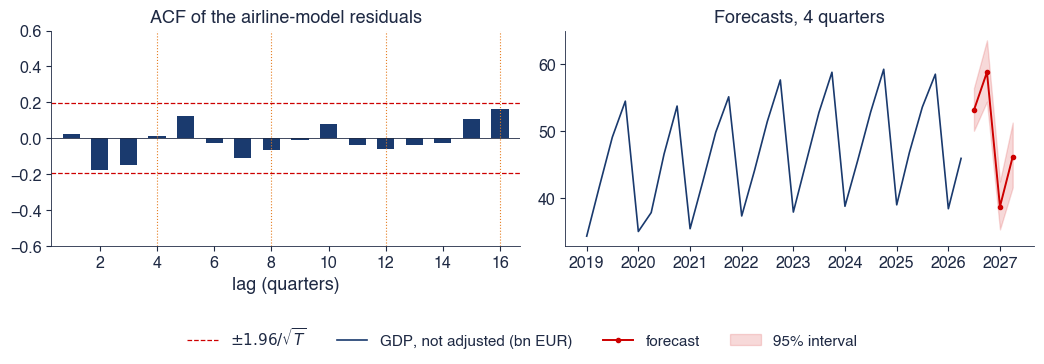

{'theta': np.float64(-0.171),
 'Theta': np.float64(-0.585),
 'theta_se': np.float64(0.109),
 'Theta_se': np.float64(0.072),
 'sigma': np.float64(3.053),
 'lb8': {'lb': 9.303282028602542, 'df': 6, 'lb_p': 0.15722636272739643},
 'f_level': array([53.082, 58.741, 38.685, 46.126]),
 'lo': array([49.999, 54.348, 35.278, 41.541]),
 'hi': array([56.356, 63.489, 42.422, 51.217]),
 'g': array([-0.835,  0.52 ,  0.826,  0.535]),
 'first_f': '2026-07-01',
 'last': '2026-04-01',
 'T': 106,
 'aicc': np.float64(520.051)}

In [13]:
# Solution
b1 = b1_gdp(save=False)
{k: (np.round(v, 3) if isinstance(v, (float, list)) else v) for k, v in b1.items()}

**Interpretation of the result.** $\hat\theta$ is not significant and $\hat\Theta \approx -0.58$: the seasonal pattern of the forecast is an exponentially weighted average of past years, with weight $1 + \hat\Theta \approx 0.42$ on the newest year. The pattern evolves, but slowly.

## B2 [Proposed]: industrial production and working days

**Question.** Does the number of working days explain part of the monthly movements of Romanian industrial production? Model: B1.

1. Estimate the airline model for $100\ln Y_t$ (with dummies for April and May 2020) with and without `working_days` as a regressor, and compare AICc and $Q^*(24)$.
2. Add two alternatives with working days, $(2,1,0)(0,1,1)_{12}$ and $(1,1,1)(0,1,1)_{12}$, and choose a model.
3. Report the working-day coefficient with its standard error, and forecast the next 12 months.
4. Interpretation: why must the working-day effect be removed before two months are compared?

**Report:** a table of AICc and p-values, one coefficient, the forecast chart and one sentence.

In [ ]:
# Your code here


## B3 [Solved]: cross-validation for daily electricity load

**Question.** Does a regression with Fourier terms and holiday dummies forecast daily load better than SARIMA and the seasonal naive method?

1. At each origin (every 28 days from 30 June 2025, horizon 14 days), fit the seasonal naive method (period 7), SARIMA$(1,0,1)(0,1,1)_7$ and a DHR (4 annual Fourier pairs, weekday and holiday dummies, ARMA(1,1) errors).
2. Compute the MAE and the MASE of each method over all origins and horizons.
3. Test DHR against SARIMA with the DM test on the window-average squared errors (one value per origin), with the HLN correction.
4. Compare the MAE on public holidays with the MAE on ordinary days.
5. Interpretation: why is the gain of the DHR largest on public holidays?

**Report:** a table of MAE and MASE, one test, the chart and one sentence.

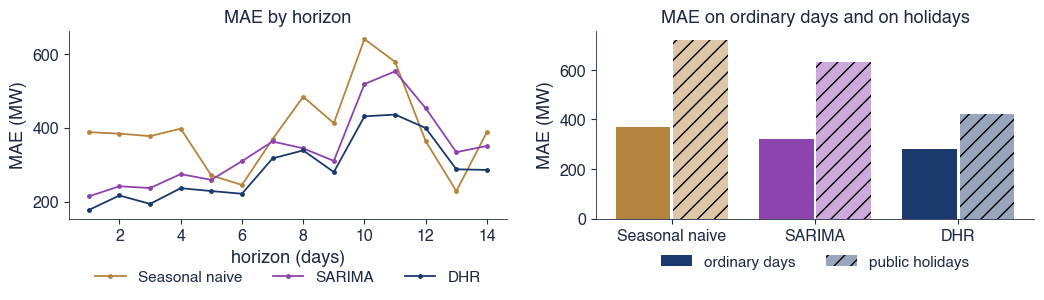

                MAE (GW)   MASE  holidays  other days
DHR                0.289  0.935     0.422       0.280
SARIMA             0.340  1.100     0.630       0.319
Seasonal naive     0.395  1.277     0.723       0.372
DM, DHR vs SARIMA: {'dbar': -0.05474885821523144, 'dm': -2.0433447671463845, 'hln': -1.9631821509026173, 'p': 0.07322457962943586, 'n': 13}
holiday and Easter coefficients: -0.374030378810789 -0.5579648595764645


In [15]:
# Solution
b3 = b3_load_cv(save=False)
print(pd.DataFrame({'MAE (GW)': b3['mae'], 'MASE': b3['mase'], 'holidays': b3['mae_hol'], 'other days': b3['mae_nohol']}).round(3))
print('DM, DHR vs SARIMA:', b3['dm'])
print('holiday and Easter coefficients:', b3['coef']['holiday'], b3['coef']['easter'])

**Interpretation of the result.** The DHR has the smallest MAE and MASE below 1; its gain is largest on holidays, which the weekly models treat as ordinary working days. Against SARIMA, the DM test is close to the 5% limit with 13 windows.

## B4 [Proposed]: seasonality in monthly inflation

**Question.** Is the seasonal pattern of Romanian monthly inflation strong enough to improve one-month forecasts? Model: B3.

1. Regress $\pi_t = 100\,\Delta\ln P_t$ (2010–2019) on 12 month dummies and test equal month means with an $F$-test.
2. Estimate the airline model for $100\ln P_t$ and report $\hat\theta$ and $\hat\Theta$.
3. From monthly origins since January 2016, forecast next month's $\pi$ with SARIMA, the seasonal naive method and the mean of the last 12 months; compare the MAE.
4. Test SARIMA against both benchmarks with the DM test (squared errors).
5. Interpretation: is the seasonal pattern strong enough to improve one-month forecasts?

**Report:** an $F$-test, two estimates, three MAE values, two DM tests and one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: tourism after the pandemic

**Question.** Which training sample gives better forecasts of tourism nights for 2023–2025: data up to 2019, or data up to 2022? Model: B1.

1. Fit the airline model to $\ln y_t$ up to December 2019 and forecast 2023–2025.
2. Repeat with data up to December 2022.
3. Compare both with the seasonal naive forecast that repeats 2022, using the MAPE.
4. Propose a better treatment of 2020–2021 (intervention dummies, a shorter sample, TBATS or Prophet) and sketch it as a team project.

**Report:** three MAPE values, the chart and a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered questions about seasonal models:

- (a) SARIMA(0,1,1)(0,1,1)$_4$ has four MA parameters, at lags 1, 4 and 5 plus the noise variance;
- (b) if the ACF of the differenced monthly series has one spike at lag 12 and the PACF decays at 12, 24, 36, use a seasonal AR(1);
- (c) unadjusted Romanian GDP fell by about 34% in the first quarter of 2026 compared with the fourth quarter of 2025: a deep recession;
- (d) DM = −2.3 with $d = L(e_1) - L(e_2)$ shows that forecast 2 is significantly more accurate;
- (e) TBATS with periods 7 and 365.25 captures the Easter dip of electricity load;
- (f) the equal-weight average of two unbiased forecasts never has a larger MSE than the average of their two MSEs.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
